In [1]:
from src.dataloading import EpiConfig, EpiDataOrchestrator, BaseLineDataLoaderManager, GraphDataLoaderManager
from src.models import ClimaScaleModel, PersistenceModel, ClimateologyModel, SimpleGCNModel, GCNLSTMModel
from src.evaluation import Evaluator

# get data
disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2011-06-01'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 4
lag_num         = 4

config = EpiConfig(
    disease             = disease_name,

    min_date            = min_date,
    max_date            = max_date,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest, 

    # quantiles           = [0.1,0.25, 0.5, 0.75, 0.9],
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,

    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,

    lag_column          = 'incidence',  
    verbose             = 0  ,

    feature_popdens     = True,
    feature_gisd        = True,
    feature_popage      = True,
    feature_popsize     = True
    )    


epidata_orchestrator  = (EpiDataOrchestrator(config)
                      .load_raw()
                      .harmonize_raw()
                      .process_data()
                      .build_features()
                      .normalize()
                      .finalize()
                      )



In [2]:
baselinedata = BaseLineDataLoaderManager(epidata_orchestrator)

persistence = PersistenceModel(baselinedata)
persistence.forecast()

climateology = ClimateologyModel(baselinedata)
climateology.forecast()

climascale = ClimaScaleModel(baselinedata)
climascale.forecast()

baseline_models = [persistence, climateology, climascale]
# baseline_models = [persistence]

baseline_evaluation = Evaluator(baseline_models).add_evaluation()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1200/1200 [00:01<00:00, 817.64it/s]


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


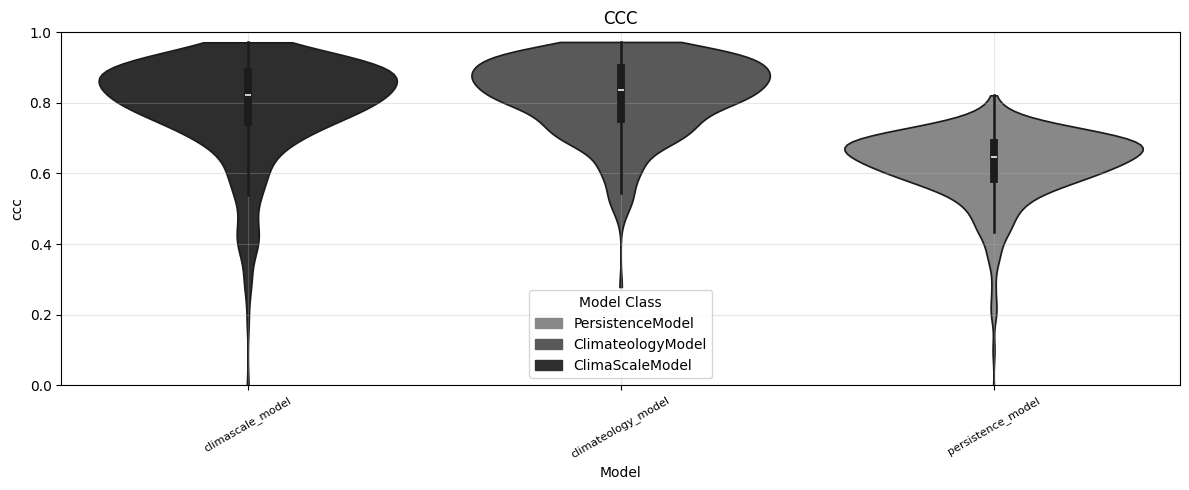

In [3]:
baseline_evaluation.plotter.plot_single_metric('ccc',0,plot_type = 'violin',vmin = 0, vmax = 1).show()

In [4]:
graphloader1 = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('test3').build()
graphloader2 = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('test1').build()
graphloader3 = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('test2').build()
graphloader4 = GraphDataLoaderManager(epidata_orchestrator).retrieve_static_graph('static_commuter24_1').build()


In [5]:
from src.models import GCN2Model, DecoupledGCNModel


==                   spatial1                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 26, 4), y=(400, 1), edge_index=(2, 400), edge_weight=(400,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.6630   |   0.8289   |    v     |           |
|  002  |   0.5643   |   0.6696   |    v     |           |
|  003  |   0.5561   |   0.6608   |    v     |           |
|  004  |   0.5576   |   0.5978   |    v     |           |
|  005  |   0.4870   |   0.5326   |    v     |           |
|  006  |   0.5407   |   0.5659   |          |   1/15    |
|  007  |   0.4730   |   0.5008   |    v     |           |
|  008  |   0.4932   |   0.4944   |    v     |           |
|  009  |   0.4753   |   0.4726   |    v     |           |
|  010  |   0.4779   |   0.4852   |          |   1/15    |
|  011  |   0.4545   |   0.4675   |    v     |           |
|  012  |   0.4640   |   0.4739   |     

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 15 epochs
Restored model from best validation loss: 0.3794
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 457.88it/s]

Test loss: 0.5726
forecasted ✓


DecoupledGCNModel(name='spatial1')

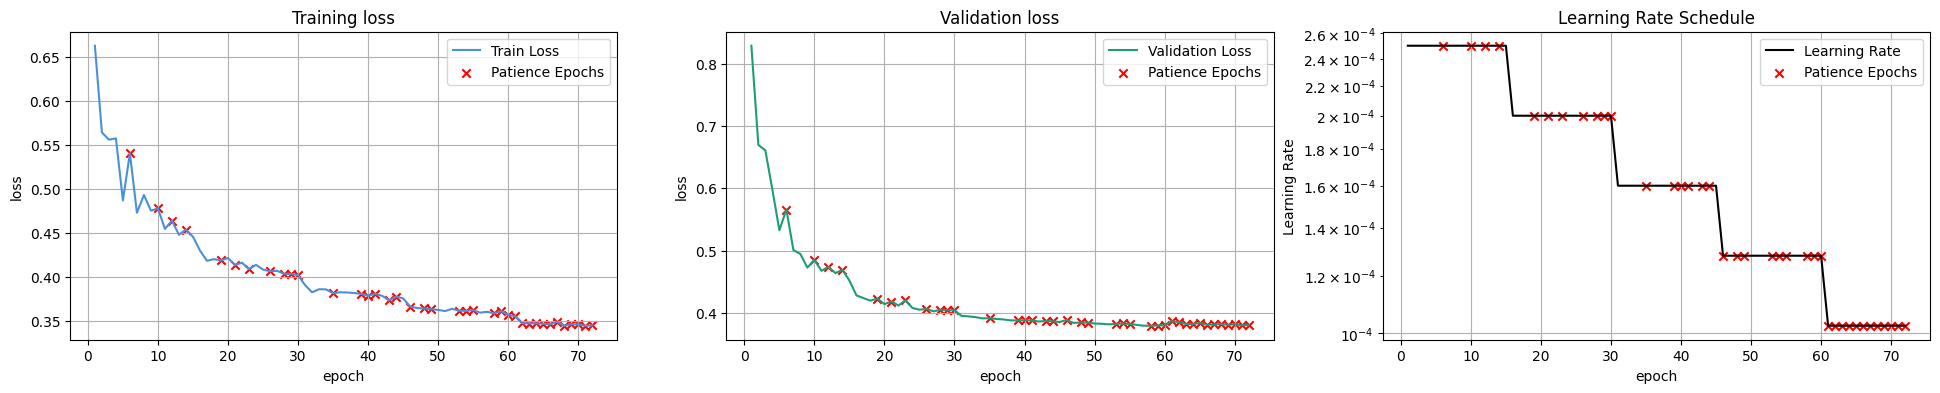

In [6]:
global_hparams = {
    'lr': 0.00025,
    'n_epochs' : 100
}

model1 = DecoupledGCNModel(graphloader1, name = 'spatial1', verbose = 2)
model1.set_model_hparams()
model1.set_global_hparams(**global_hparams)
model1.train()
model1.forecast()


==                   spatial2                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 26, 4), y=(400, 1), edge_index=(2, 2088), edge_weight=(2088,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.6497   |   0.7516   |    v     |           |
|  002  |   0.5693   |   0.6813   |    v     |           |
|  003  |   0.5443   |   0.6969   |          |   1/15    |
|  004  |   0.5489   |   0.4869   |    v     |           |
|  005  |   0.5258   |   0.4777   |    v     |           |
|  006  |   0.4736   |   0.4731   |    v     |           |
|  007  |   0.5004   |   0.4328   |    v     |           |
|  008  |   0.4613   |   0.4300   |    v     |           |
|  009  |   0.4667   |   0.4183   |    v     |           |
|  010  |   0.4533   |   0.4230   |          |   1/15    |
|  011  |   0.4564   |   0.4119   |    v     |           |
|  012  |   0.4432   |   0.4158   |   

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Early stopping: Validation loss hasn't improved for 15 epochs
Restored model from best validation loss: 0.3298
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 457.57it/s]

Test loss: 0.5772
forecasted ✓


DecoupledGCNModel(name='spatial2')

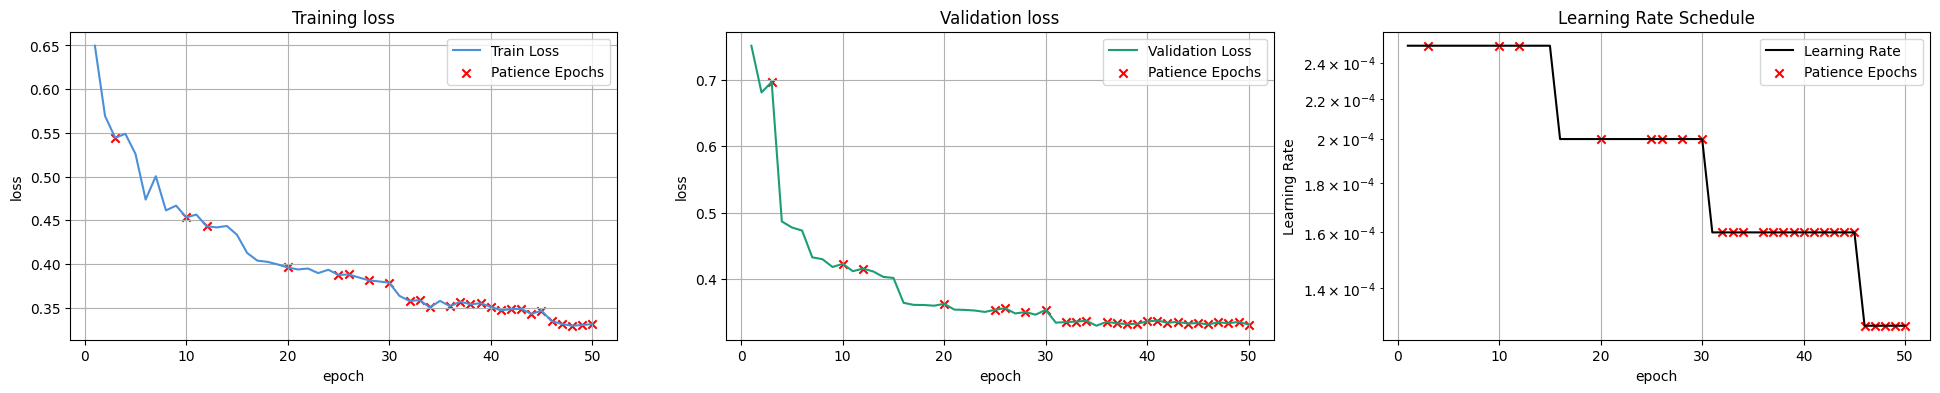

In [7]:
model2 = DecoupledGCNModel(graphloader2, name = 'spatial2', verbose = 2)
model2.set_model_hparams()
model2.set_global_hparams(**global_hparams)
model2.train()
model2.forecast()


==                   spatial3                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 26, 4), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.6708   |   1.0538   |    v     |           |
|  002  |   0.5686   |   0.8516   |    v     |           |
|  003  |   0.5747   |   0.7578   |    v     |           |
|  004  |   0.5469   |   0.5284   |    v     |           |
|  005  |   0.5292   |   0.4858   |    v     |           |
|  006  |   0.4760   |   0.5139   |          |   1/15    |
|  007  |   0.4947   |   0.4733   |    v     |           |
|  008  |   0.4728   |   0.4734   |          |   1/15    |
|  009  |   0.4676   |   0.4605   |    v     |           |
|  010  |   0.4623   |   0.4615   |          |   1/15    |
|  011  |   0.4590   |   0.4402   |    v     |           |
|  012  |   0.4496   |   0.4399   |   

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


|  100  |   0.2911   |   0.3310   |          |   11/15   |
trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 457.32it/s]

Test loss: 0.5492
forecasted ✓


DecoupledGCNModel(name='spatial3')

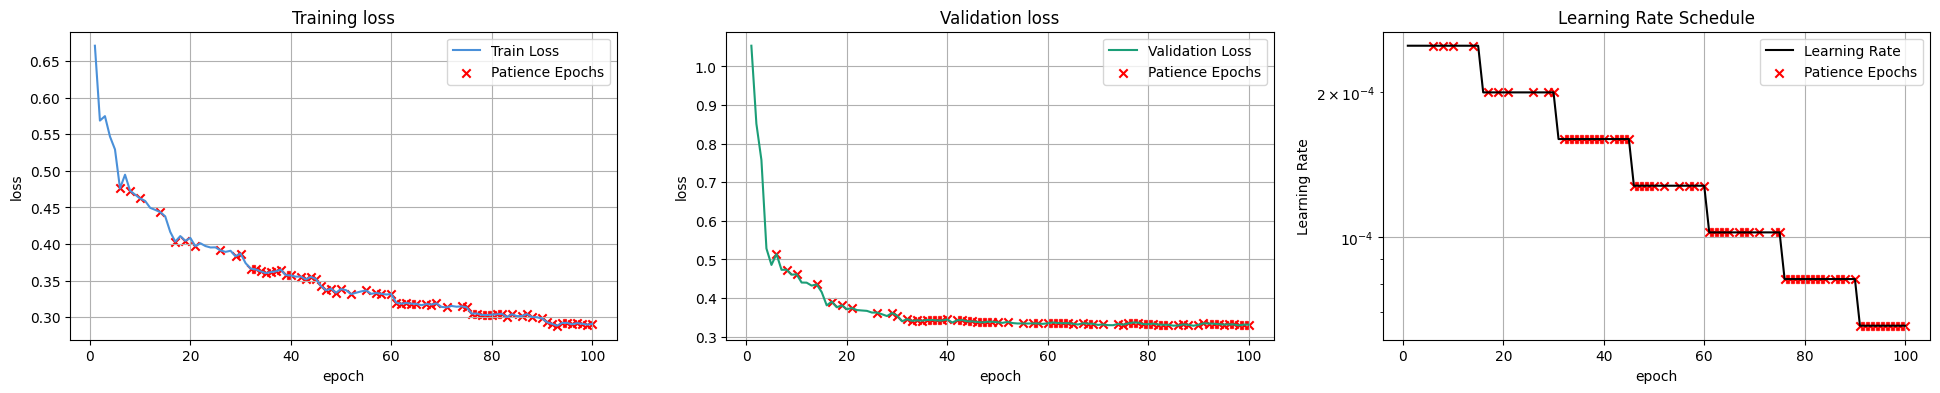

In [8]:
model3 = DecoupledGCNModel(graphloader3, name = 'spatial3', verbose = 2)
model3.set_model_hparams()
model3.set_global_hparams(**global_hparams)
model3.train()
model3.forecast()


==                   spatial4                   ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 26, 4), y=(400, 1), edge_index=(2, 3905), edge_weight=(3905,))
──────────────────────────────────────────────────────────
| EPOCH | TRAIN LOSS |  VAL LOSS  | NEW BEST | PATIENCE  |
|  001  |   0.6993   |   1.1246   |    v     |           |
|  002  |   0.5653   |   0.7408   |    v     |           |
|  003  |   0.5923   |   0.5941   |    v     |           |
|  004  |   0.5449   |   0.5720   |    v     |           |
|  005  |   0.5279   |   0.4960   |    v     |           |
|  006  |   0.4759   |   0.5215   |          |   1/15    |
|  007  |   0.4989   |   0.4713   |    v     |           |
|  008  |   0.4657   |   0.4504   |    v     |           |
|  009  |   0.4609   |   0.4350   |    v     |           |
|  010  |   0.4510   |   0.4480   |          |   1/15    |
|  011  |   0.4454   |   0.4325   |    v     |           |
|  012  |   0.4465   |   0.4279   |   

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:335: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


trained ✓


Forecasting test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 53/53 [00:00<00:00, 456.07it/s]

Test loss: 0.5702
forecasted ✓


DecoupledGCNModel(name='spatial4')

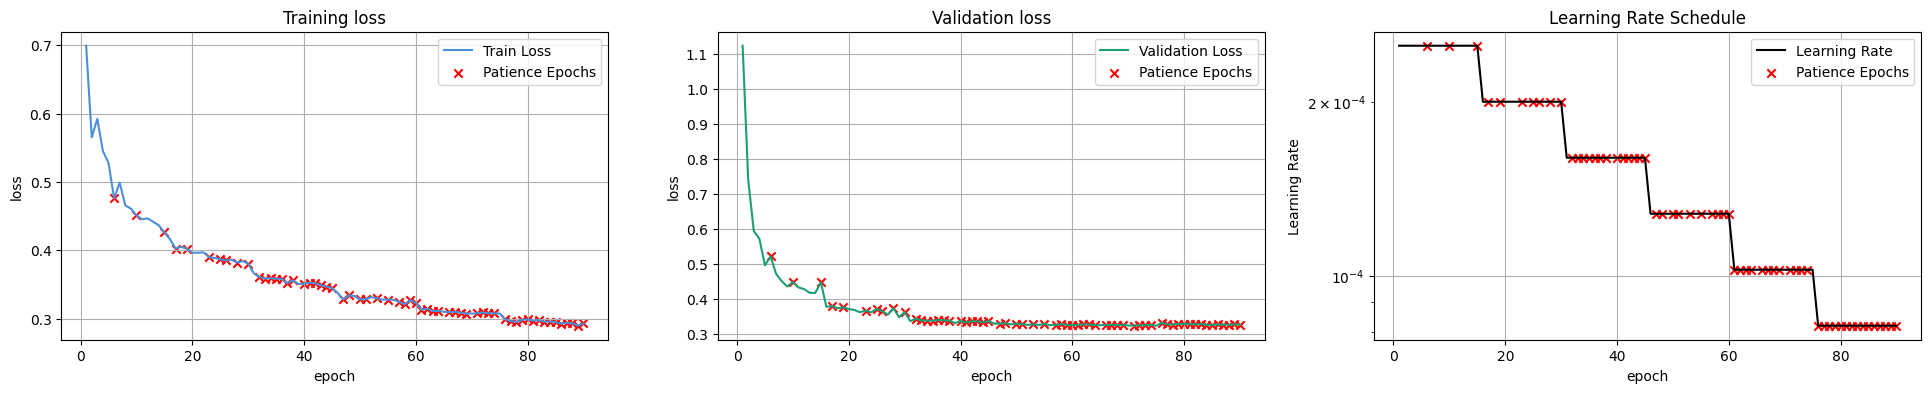

In [9]:
model4 = DecoupledGCNModel(graphloader4, name = 'spatial4', verbose = 2)
model4.set_model_hparams()
model4.set_global_hparams(**global_hparams)
model4.train()
model4.forecast()

In [10]:
models = [model1, model2, model3, model4]

model_evaluation = Evaluator(baseline_models + models).add_evaluation()

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2800/2800 [00:03<00:00, 766.02it/s]


/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:153: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)


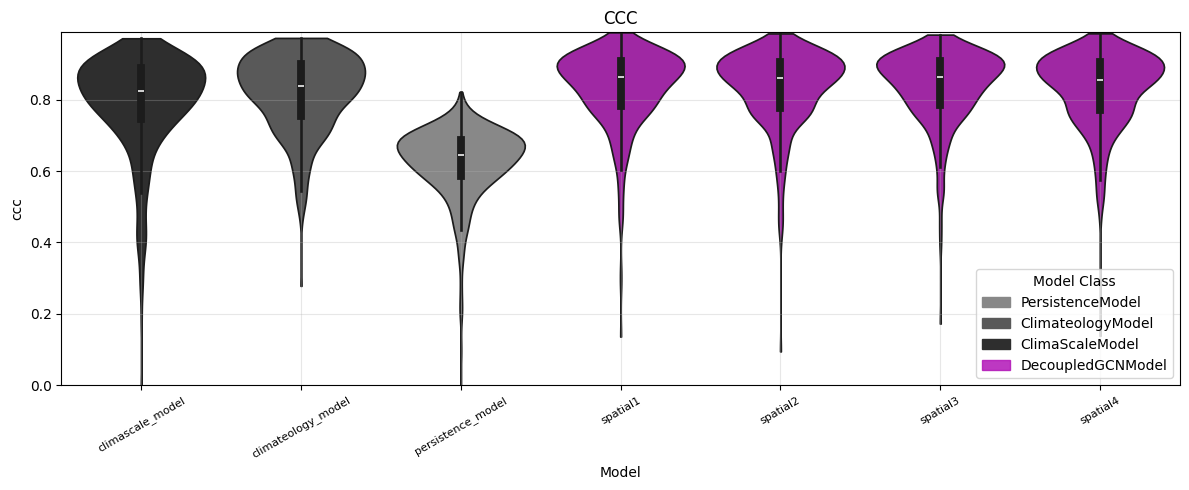

In [11]:
model_evaluation.plotter.plot_single_metric('ccc',0,plot_type = 'violin', vmin = 0, log=False).show()

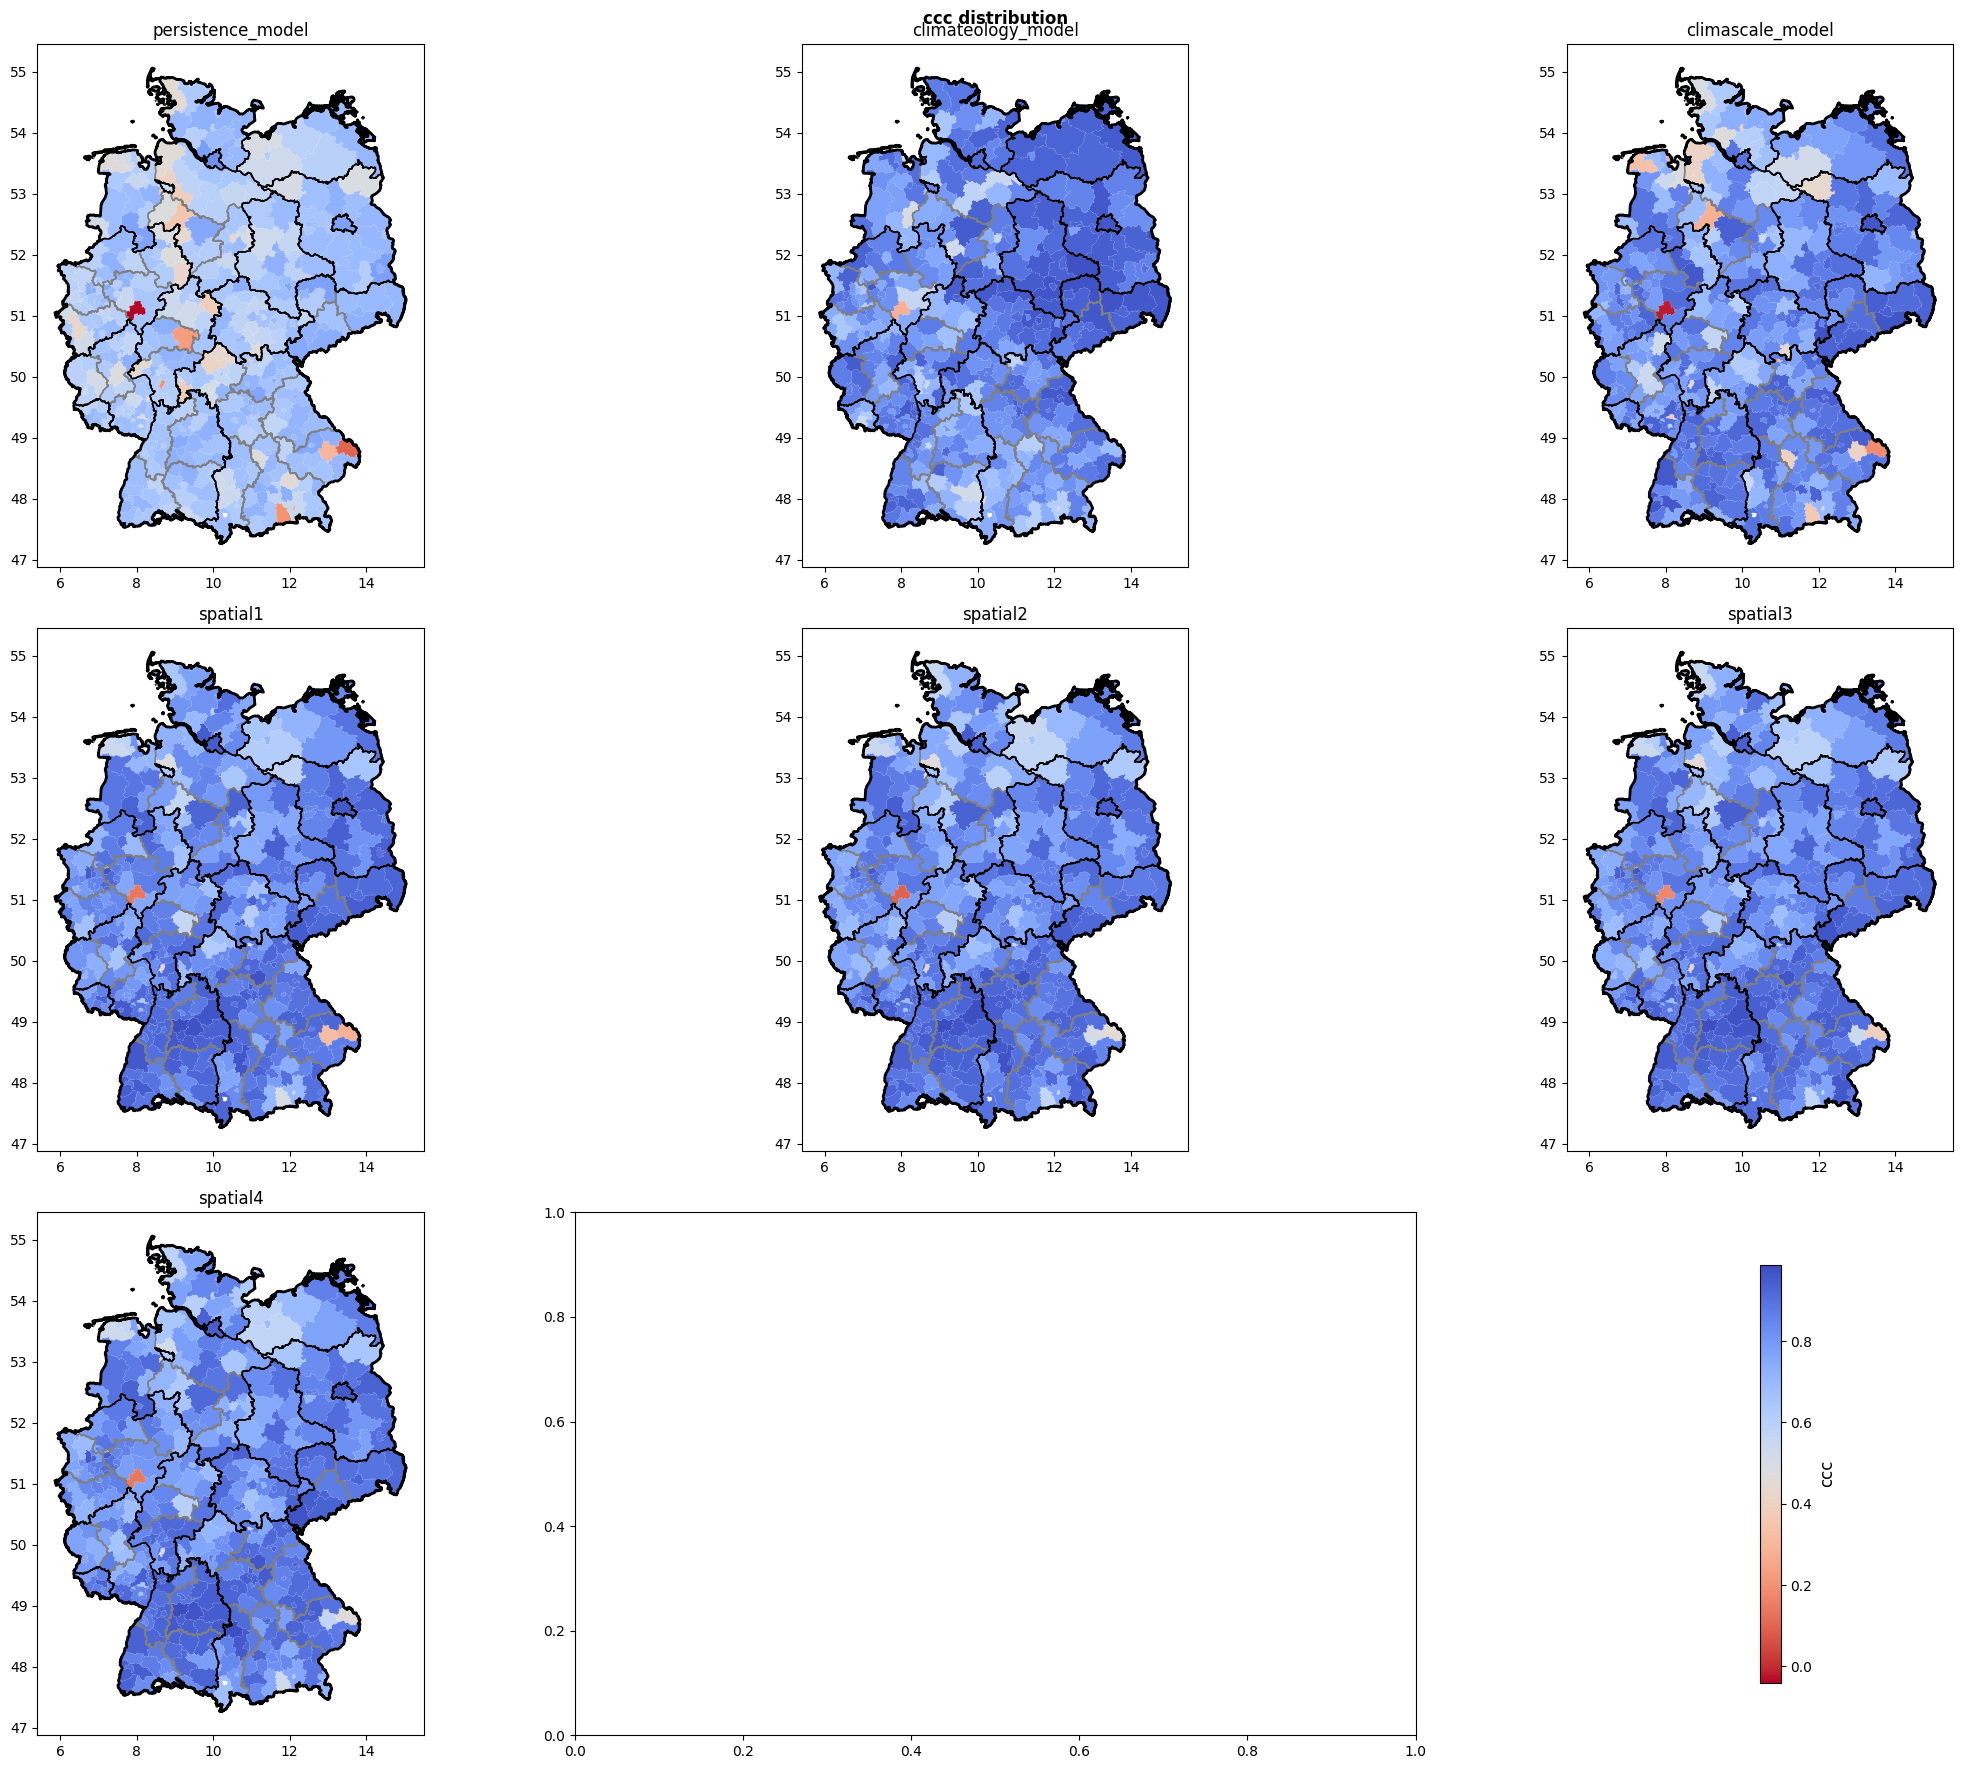

In [12]:
model_evaluation.plotter.plot_single_metric('ccc',0,plot_type = 'map', vmin = 0, log=False, reverse_scale=True)

In [37]:
metrics = ['ccc']


metrics_df = model_evaluation.data_compilation.get_data(0,'test')['metrics']

model_cols = list(metrics_df['model'].unique())

for metric in metrics:
    df_long = metrics_df[['nuts_node','model',metric]]
    df_wide = df_long.pivot_table(index = 'nuts_node', columns = 'model', values = metric).reset_index(drop = False).reset_index(drop = True)
    df_wide['best'] = df_wide[model_cols].idxmax(axis=1)

In [39]:
df_wide

model,nuts_node,climascale_model,climateology_model,persistence_model,spatial1,spatial2,spatial3,spatial4,best
0,0,0.730673,0.882976,0.517898,0.796292,0.745056,0.738703,0.707296,climateology_model
1,1,0.731935,0.891591,0.684280,0.831473,0.882644,0.856681,0.877677,climateology_model
2,2,0.784667,0.865552,0.660735,0.833709,0.789700,0.797303,0.789906,climateology_model
3,3,0.374372,0.698626,0.595081,0.602263,0.583441,0.549272,0.612620,climateology_model
4,4,0.642187,0.645211,0.700824,0.810869,0.822130,0.794299,0.774306,spatial2
...,...,...,...,...,...,...,...,...,...
394,395,0.824341,0.927490,0.564209,0.774762,0.758065,0.755410,0.726277,climateology_model
395,396,0.783396,0.932105,0.625085,0.771590,0.829642,0.855492,0.884666,climateology_model
396,397,0.723292,0.907805,0.601773,0.774038,0.808819,0.782384,0.757889,climateology_model
397,398,0.971699,0.964094,0.685589,0.913747,0.903143,0.914618,0.934371,climascale_model


In [ ]:
import seaborn as sns 

import pandas as pd
shp = epidata_orchestrator._data_context.shapedata_node

shp = pd.merge(shp, df_wide, on = 'nuts_node')

model,nuts_node,climascale_model,climateology_model,persistence_model,spatial1,spatial2,spatial3,spatial4,best
0,0,0.730673,0.882976,0.517898,0.796292,0.745056,0.738703,0.707296,climateology_model
1,1,0.731935,0.891591,0.684280,0.831473,0.882644,0.856681,0.877677,climateology_model
2,2,0.784667,0.865552,0.660735,0.833709,0.789700,0.797303,0.789906,climateology_model
3,3,0.374372,0.698626,0.595081,0.602263,0.583441,0.549272,0.612620,climateology_model
4,4,0.642187,0.645211,0.700824,0.810869,0.822130,0.794299,0.774306,spatial2
...,...,...,...,...,...,...,...,...,...
394,395,0.824341,0.927490,0.564209,0.774762,0.758065,0.755410,0.726277,climateology_model
395,396,0.783396,0.932105,0.625085,0.771590,0.829642,0.855492,0.884666,climateology_model
396,397,0.723292,0.907805,0.601773,0.774038,0.808819,0.782384,0.757889,climateology_model
397,398,0.971699,0.964094,0.685589,0.913747,0.903143,0.914618,0.934371,climascale_model


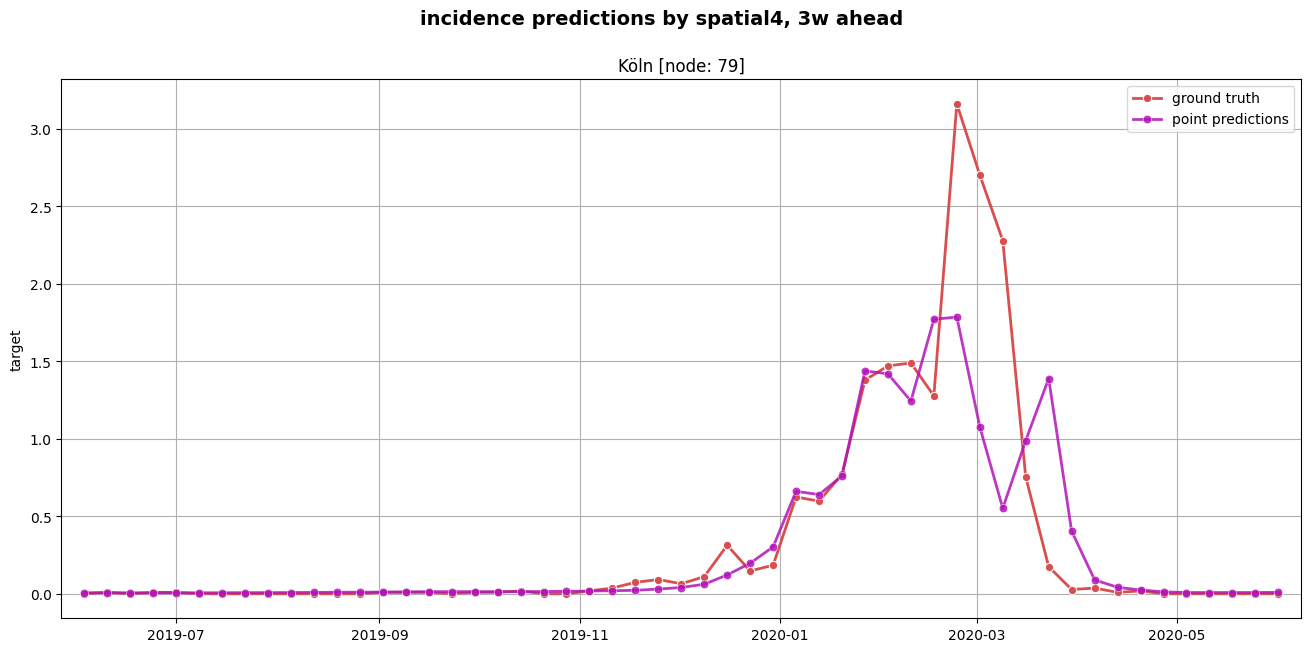

In [27]:

model4.show_forecasts(79).show()

In [132]:
difficult_nodes = [  3,   6,  31,  38,  44,  48,  50,  60, 112, 116, 134, 224, 236, 248, 249, 269, 338, 347, 349]

In [129]:
import seaborn as sns
metrics = model_evaluation.data_compilation.get_data(0,'test')['metrics']
metrics_sel = metrics[['nuts_node','model','ccc']]
metrics_sel = metrics_sel.pivot_table(columns = 'model', values = 'ccc', index = 'nuts_node').reset_index(drop = False)

In [130]:
model_sel = metrics_sel[['nuts_node','spatial1','spatial2','spatial3']]
print(model_sel[(model_sel[['spatial1','spatial2','spatial3']] < 0.6).any(axis=1)]['nuts_node'].index)

Index([  3,   6,  31,  38,  44,  48,  50,  60, 112, 116, 134, 224, 236, 248,
       249, 269, 338, 347, 349],
      dtype='int64')


(-0.7502293674309588, 0.4165605514437629)

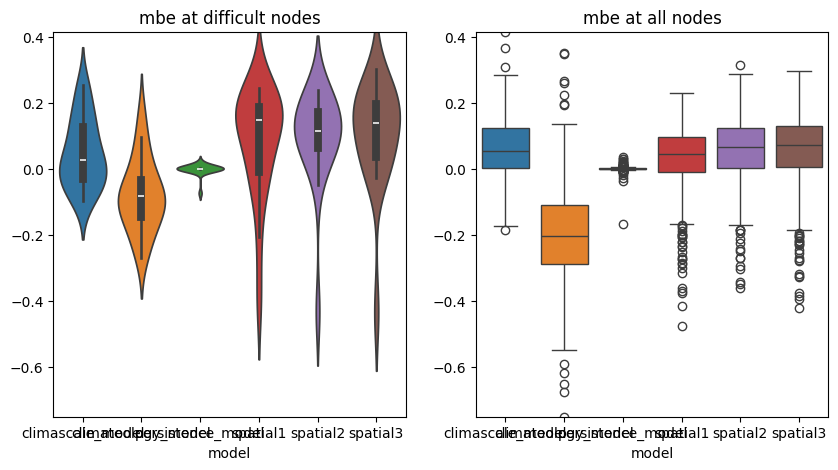

In [164]:
import matplotlib.pyplot as plt

metric = 'mbe'
metrics = model_evaluation.data_compilation.get_data(0,'test')['metrics']
metrics_sel = metrics[['nuts_node','model',metric]]
metrics_sel = metrics_sel.pivot_table(columns = 'model', values = metric, index = 'nuts_node').reset_index(drop = False)
metrics_sel1= metrics_sel[metrics_sel['nuts_node'].isin(difficult_nodes)]
metrics_sel1 = metrics_sel1.set_index('nuts_node')

lim1, lim2 = metrics[metric].min(), metrics[metric].max()

# control:
metrics_sel2= metrics_sel[~metrics_sel['nuts_node'].isin(difficult_nodes)]
metrics_sel2 = metrics_sel2.set_index('nuts_node')

fig, axes = plt.subplots(1,2, figsize = (10,5))

sns.violinplot(metrics_sel1, ax = axes[0])
sns.boxplot(metrics_sel2,ax = axes[1])

axes[0].set_title(f'{metric} at difficult nodes')
axes[1].set_title(f'{metric} at all nodes')

axes[0].set_ylim(lim1,lim2)
axes[1].set_ylim(lim1,lim2)

<Axes: xlabel='model'>

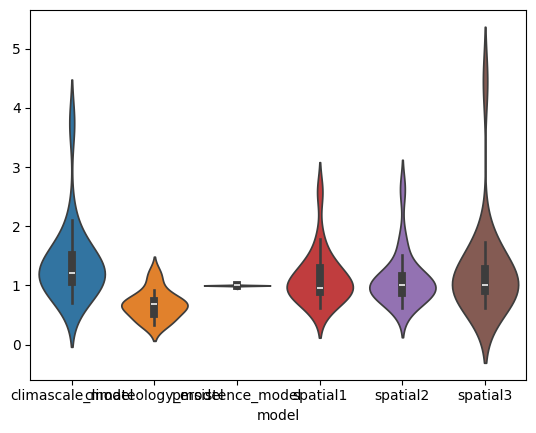

In [ ]:

metrics_sel['gap_idenity']    = metrics_sel['persistence_model'] - metrics_sel['spatial1']
metrics_sel['gap_geononself'] = metrics_sel['persistence_model'] - metrics_sel['spatial2']
metrics_sel['gap_geoself']    = metrics_sel['persistence_model'] - metrics_sel['spatial3']
metrics_sel['gap_ig']         = metrics_sel['spatial1'] - metrics_sel['spatial2']

<Axes: >

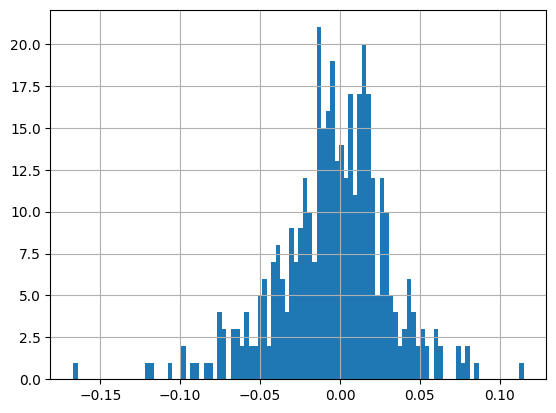

In [ ]:
metrics_sel